# Probability of Nth Recall

> Compute and visualize which study positions produce the nth recall.

The probability of nth recall (PNR) examines which study positions are recalled at each output position. For example, the first-recall PNR shows that the last few items studied (recency positions) are most likely to be recalled first, reflecting the strong recency effect in immediate free recall [@howard1999maintained].

The conditional variant divides the number of times a position was actually recalled at output position $n$ by the number of times it was still available (not yet recalled), giving a probability conditioned on availability.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `query_recall_position` | 0-based recall output position to analyze |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.pnr import (
    available_recalls,
    conditional_fixed_pres_pnr,
    conditional_pnr_with_repeats,
    fixed_pres_pnr,
    plot_pnr,
    pnr,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "PNR"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"
query_recall_position = 0

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

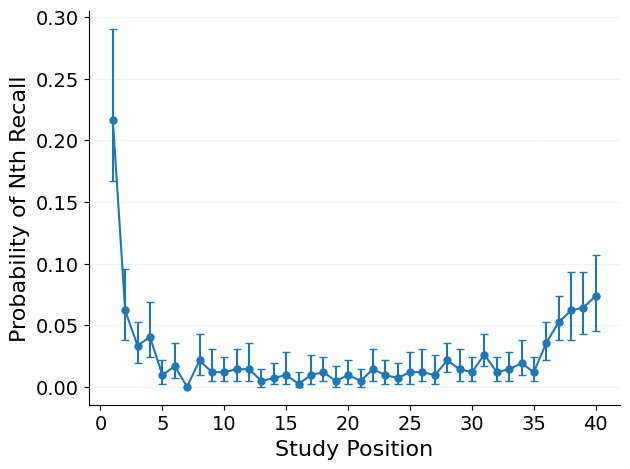

In [5]:
#| code-summary: Plot probability of nth recall
#| label: fig-pnr
#| fig-cap: "Probability of nth recall as a function of study position."
plot_pnr(data, trial_mask, query_recall_position=query_recall_position)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

Each dataset is paired with its corresponding mask by index. The `query_recall_position` parameter selects which output position to analyze (0 for first recall, 1 for second, etc.).

In [6]:
#| echo: false
show_doc(plot_pnr)

---

### plot_pnr

>      plot_pnr (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr.typ
>                ing.RecallDataset], trial_masks:Union[Sequence[jaxtyping.Bool[A
>                rray,'trial_count']],jaxtyping.Bool[Array,'trial_count']],
>                query_recall_position:int=0,
>                color_cycle:Optional[list[str]]=None,
>                labels:Optional[Sequence[str]]=None,
>                contrast_name:Optional[str]=None,
>                axis:Optional[matplotlib.axes._axes.Axes]=None, size:int=3,
>                confidence_level:float=0.95)

*Plot probability of nth recall with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| query_recall_position | int | 0 | 0-based recall index to plot. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the PNR plot.** |

The `plot_pnr` function uses `conditional_pnr_with_repeats` internally. For fixed-length lists with no repetition, `fixed_pres_pnr` and `conditional_fixed_pres_pnr` provide simpler interfaces.

In [7]:
#| echo: false
show_doc(conditional_pnr_with_repeats)

---

### conditional_pnr_with_repeats

>      conditional_pnr_with_repeats (dataset:jaxcmr.typing.RecallDataset,
>                                    size:int, query_recall_position:int)

*Conditional PNR when study items may repeat.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | Max study positions an item can occupy. |
| query_recall_position | int | 0-based recall index to analyze. |
| **Returns** | **Float[Array, 'list_length']** | **Conditional probability at each study position.** |

In [8]:
#| echo: false
show_doc(pnr)

---

### pnr

>      pnr (dataset:jaxcmr.typing.RecallDataset, size:int=3,
>           query_recall_position:int=0)

*Probability of nth recall with item repetitions.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Max study positions an item can occupy. |
| query_recall_position | int | 0 | 0-based recall index to analyze. |
| **Returns** | **Float[Array, 'study_positions']** |  | **Recall probability at each study position.** |

In [9]:
# Repeated items distribute probability across their positions
recalls = jnp.array([[1, 0], [1, 0]])
presentations = jnp.array([[1, 2, 1], [1, 2, 1]])

dataset = {
    "subject": jnp.ones((2, 1), dtype=jnp.int32),
    "listLength": jnp.full((2, 1), 3, dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": recalls,
}

result = pnr(dataset, size=2)
assert jnp.allclose(result, jnp.array([1.0, 0.0, 1.0]))

### Fixed-presentation variants

These functions operate directly on serial-position-coded recall arrays without needing presentation information.

In [10]:
#| echo: false
show_doc(fixed_pres_pnr)

---

### fixed_pres_pnr

>      fixed_pres_pnr
>                      (recalls:jaxtyping.Integer[Array,'trial_countrecall_posit
>                      ions'], list_length:int, query_recall_position:int=0)

*Probability of nth recall by study position.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| recalls | Integer[Array, 'trial_count recall_positions'] |  | 1-indexed recall array; 0 for no recall. |
| list_length | int |  | Number of items in the study list. |
| query_recall_position | int | 0 | 0-based recall index to analyze. |
| **Returns** | **Float[Array, 'study_positions']** |  | **Recall probability at each study position.** |

In [11]:
# First recall probabilities across two trials
recalls = jnp.array([[1, 2, 0], [2, 1, 0]])
result = fixed_pres_pnr(recalls, list_length=3)
assert jnp.allclose(result, jnp.array([0.5, 0.5, 0.0]))

In [12]:
#| echo: false
show_doc(conditional_fixed_pres_pnr)

---

### conditional_fixed_pres_pnr

>      conditional_fixed_pres_pnr
>                                  (recalls:jaxtyping.Integer[Array,'trialrecall
>                                  _positions'], list_length:int,
>                                  query_recall_position:int)

*Conditional PNR: actual over available per position.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| recalls | Integer[Array, 'trial recall_positions'] | 1-indexed recall array. |
| list_length | int | Number of items in the study list. |
| query_recall_position | int | 0-based recall index to analyze. |
| **Returns** | **Float[Array, 'list_length']** | **Conditional probability at each study position.** |

### Utilities

In [13]:
#| echo: false
show_doc(available_recalls)

---

### available_recalls

>      available_recalls (recalls:jaxtyping.Integer[Array,'recall_positions'],
>                         query_recall_position:int, list_length:int)

*Mask of study positions available at a recall position.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| recalls | Integer[Array, 'recall_positions'] | 1-indexed recalls for a single trial. |
| query_recall_position | int | Index in the recall sequence to evaluate. |
| list_length | int | Number of items in the study list. |
| **Returns** | **Bool[Array, 'list_length']** | **True for positions not yet recalled.** |

In [14]:
# Prior recalls mark positions as unavailable
recalls = jnp.array([1, 0, 0])
mask = available_recalls(recalls, query_recall_position=1, list_length=3)
assert jnp.array_equal(mask, jnp.array([False, True, True]))